# Сводка результатов

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

targets = ["next_session", "crm_7d"]
sessionlevel = ["linear", "nn", "catboost", "ensemble"]

res = pd.concat([pd.read_csv(f) for f in ["/kaggle/input/datasets/vikakolganova/linres/linres.csv", "/kaggle/input/datasets/vikakolganova/nnresc/nnres.csv", "/kaggle/input/datasets/vikakolganova/arimax/arimaxres.csv", "/kaggle/input/datasets/vikakolganova/catres/catres.csv", "/kaggle/input/datasets/vikakolganova/enresx/ensres.csv"]],
                ignore_index=True)
res.to_csv("participant3_results.csv", index=False)
print(len(res), "строк")

49 строк


In [2]:
preds = {}
for f in ["/kaggle/input/datasets/vikakolganova/linepreds/linpreds.npz", "/kaggle/input/datasets/vikakolganova/nnpreds/nnpreds.npz", "/kaggle/input/datasets/vikakolganova/catpreds/catpreds.npz", "/kaggle/input/datasets/vikakolganova/enspreds/enspreds.npz"]:
    z = np.load(f)
    for k in z.files:
        lab, name = k.split("|")
        preds[(lab, name)] = z[k]
print(len(preds), "наборов предсказаний")

46 наборов предсказаний


## Таблицы по таргетам

In [3]:
cols = ["model_family", "model_name", "target_mode", "val_mae", "val_medae", "val_p70_abs_error",
        "val_p90_abs_error", "val_r2", "val_product_mae", "val_engagement_risk_mae",
        "val_small_mae", "val_normal_mae", "val_long_mae", "test_mae", "backtest_mae_std", "fit_sec"]
for lab in targets:
    print(lab)
    sub = res[(res["target_label"] == lab) & (res["model_family"].isin(sessionlevel))].sort_values("val_mae")
    display(sub[cols].round(2))
print("ARIMAX, дневной уровень")
display(res[res["model_family"] == "arimax"][["target_label", "model_name", "val_mae", "val_r2"]].round(2))

next_session


,model_family,model_name,target_mode,val_mae,val_medae,val_p70_abs_error,val_p90_abs_error,val_r2,val_product_mae,val_engagement_risk_mae,val_small_mae,val_normal_mae,val_long_mae,test_mae,backtest_mae_std,fit_sec
42,catboost,cat_seed_ensemble,log1p_p995,556.93,260.60,476.10,1237.79,0.02,262.66,275.24,229.77,307.32,2017.36,600.69,NaN,0.0
45,catboost,cat_blend_w75,blend,557.11,261.06,477.54,1240.92,0.03,264.16,276.49,231.00,308.88,2011.70,600.70,NaN,0.0
37,catboost,cat_leaf_gradient_3,log1p_p995,557.13,258.86,477.21,1240.40,0.02,263.24,275.96,230.05,309.10,2014.07,600.54,7.66,7.1
44,catboost,cat_blend_w50,blend,557.16,261.29,478.49,1243.27,0.03,264.14,276.42,231.14,308.32,2012.71,600.66,NaN,0.0
48,ensemble,cat_nn_w70,log1p_p995,557.24,241.60,459.72,1286.72,0.01,246.83,259.23,197.62,322.19,2081.53,601.90,NaN,0.0
43,catboost,cat_blend_w25,blend,557.27,261.19,477.86,1238.98,0.03,264.43,276.41,231.31,307.90,2013.72,600.71,NaN,0.0
36,catboost,cat_leaf_gradient_1,log1p_p995,557.36,254.84,472.36,1243.46,0.02,260.01,272.46,224.72,308.68,2031.74,600.54,NaN,7.8
27,catboost,cat_ordered_hastime,log1p_p995,557.56,257.68,474.25,1246.40,0.02,261.79,274.52,226.93,310.84,2022.09,600.53,NaN,15.8
30,catboost,cat_capped_target,p995,557.56,262.39,477.73,1240.67,0.03,265.26,277.43,234.32,304.81,2013.17,600.59,NaN,5.7
39,catboost,cat_odwait_50,log1p_p995,557.85,261.36,481.69,1238.17,0.03,266.84,279.21,234.89,309.55,2003.45,600.83,NaN,6.1


crm_7d


,model_family,model_name,target_mode,val_mae,val_medae,val_p70_abs_error,val_p90_abs_error,val_r2,val_product_mae,val_engagement_risk_mae,val_small_mae,val_normal_mae,val_long_mae,test_mae,backtest_mae_std,fit_sec
28,catboost,cat_plain_hastime,log1p_p995,264.55,152.90,276.87,579.12,0.30,181.35,186.87,176.85,183.10,898.46,262.66,5.57,10.1
33,catboost,cat_capped_target,p995,265.33,154.15,283.82,572.09,0.31,184.26,189.76,183.08,184.20,885.63,263.67,NaN,10.0
29,catboost,cat_ordered_hastime,log1p_p995,266.18,155.98,278.16,578.36,0.30,182.97,188.50,178.60,184.64,900.35,261.83,NaN,16.0
34,catboost,cat_quantile_40,log1p_p995,268.55,145.62,267.93,607.11,0.24,169.22,176.33,137.08,188.58,989.53,268.96,NaN,10.0
35,catboost,cat_quantile_35,log1p_p995,275.61,148.62,271.48,631.10,0.20,169.59,176.92,122.47,197.66,1032.77,275.25,NaN,10.1
16,linear,huber_p995,p995,308.03,197.76,318.57,649.08,0.17,212.23,229.93,260.65,201.15,992.62,304.24,NaN,8.2
13,linear,huber_raw,raw,308.12,197.44,318.75,649.85,0.17,212.30,230.14,260.37,201.67,991.22,304.35,NaN,10.0
23,nn,nn_num_qt_mae,log1p_p995,316.86,194.14,337.31,705.46,0.12,210.79,220.77,162.42,244.22,1047.90,313.68,NaN,4.9
14,linear,ridge_p995,p995,323.97,235.40,358.42,622.12,0.21,248.07,262.09,348.47,201.31,938.14,325.72,NaN,0.0
15,linear,elasticnet_p995,p995,324.17,235.49,358.89,622.48,0.21,248.32,262.26,348.95,201.28,939.03,325.70,NaN,2.8


ARIMAX, дневной уровень


,target_label,model_name,val_mae,val_r2
24,next_session,"arimax_(1, 1, 1)_s0",6.53,0.48
25,crm_7d,"arimax_(1, 1, 1)_s0",9.53,0.18


In [4]:
for lab in targets:
    sub = res[(res["target_label"] == lab) & res["val_mae"].notna() & (res["model_family"].isin(sessionlevel))]
    print(lab)
    print("  best_by_mae            ", sub.loc[sub["val_mae"].idxmin(), "model_name"])
    print("  best_by_product_mae    ", sub.loc[sub["val_product_mae"].idxmin(), "model_name"])
    print("  best_by_engagement_risk", sub.loc[sub["val_engagement_risk_mae"].idxmin(), "model_name"])

next_session
  best_by_mae             cat_seed_ensemble
  best_by_product_mae     cat_quantile_35
  best_by_engagement_risk cat_quantile_35
crm_7d
  best_by_mae             cat_plain_hastime
  best_by_product_mae     cat_quantile_40
  best_by_engagement_risk cat_quantile_40


## Сравнение моделей

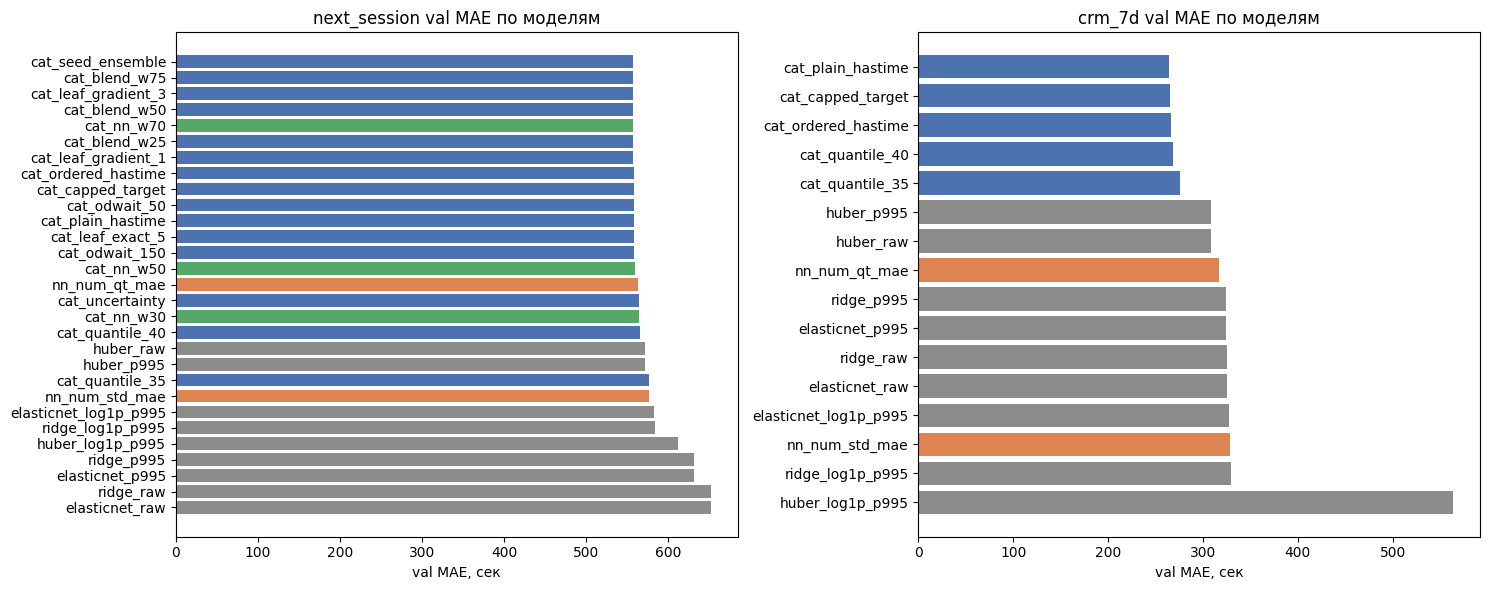

In [5]:
colors = {"linear": "#8c8c8c", "nn": "#dd8452", "catboost": "#4c72b0", "ensemble": "#55a868"}
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, lab in zip(axes, targets):
    sub = res[(res["target_label"] == lab) & (res["model_family"].isin(sessionlevel))].sort_values("val_mae")
    ax.barh(sub["model_name"], sub["val_mae"], color=[colors[f] for f in sub["model_family"]])
    ax.invert_yaxis()
    ax.set_title(lab + " val MAE по моделям")
    ax.set_xlabel("val MAE, сек")
plt.tight_layout()
plt.show()

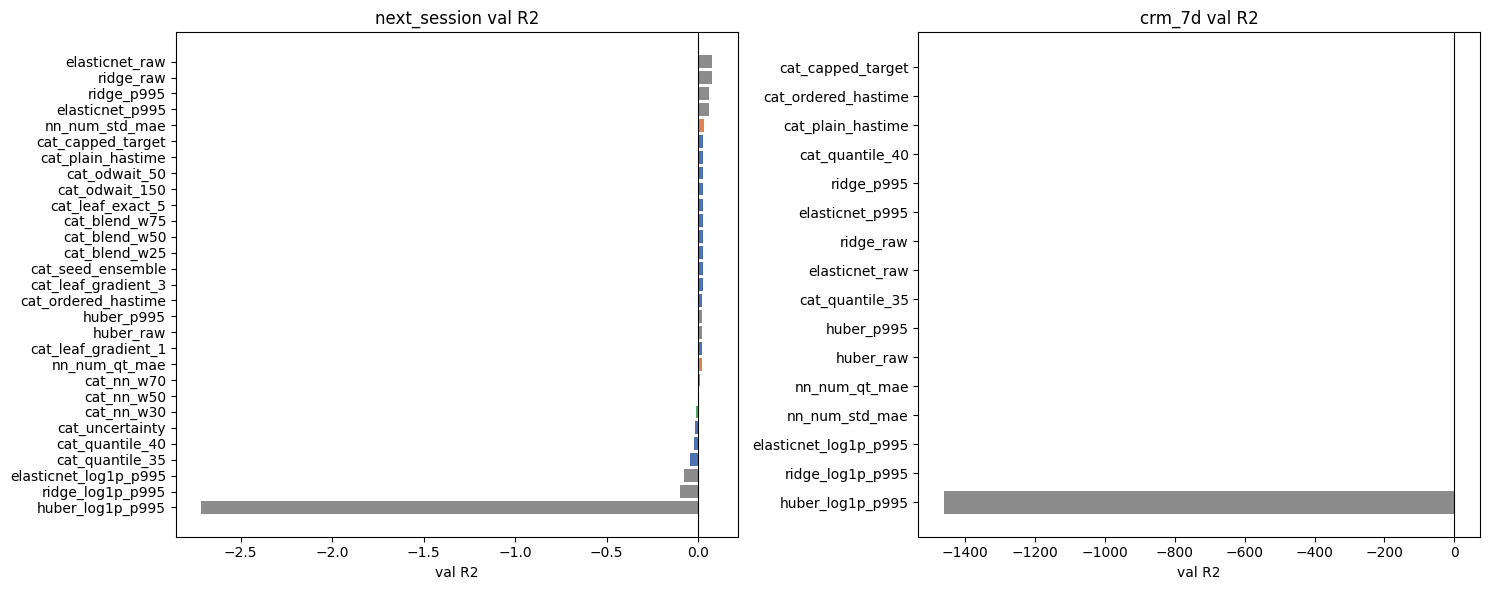

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, lab in zip(axes, targets):
    sub = res[(res["target_label"] == lab) & (res["model_family"].isin(sessionlevel))].sort_values("val_r2")
    ax.barh(sub["model_name"], sub["val_r2"], color=[colors[f] for f in sub["model_family"]])
    ax.axvline(0, color="k", lw=0.8)
    ax.set_title(lab + " val R2")
    ax.set_xlabel("val R2")
plt.tight_layout()
plt.show()

## Трейд-офф стратегий таргета

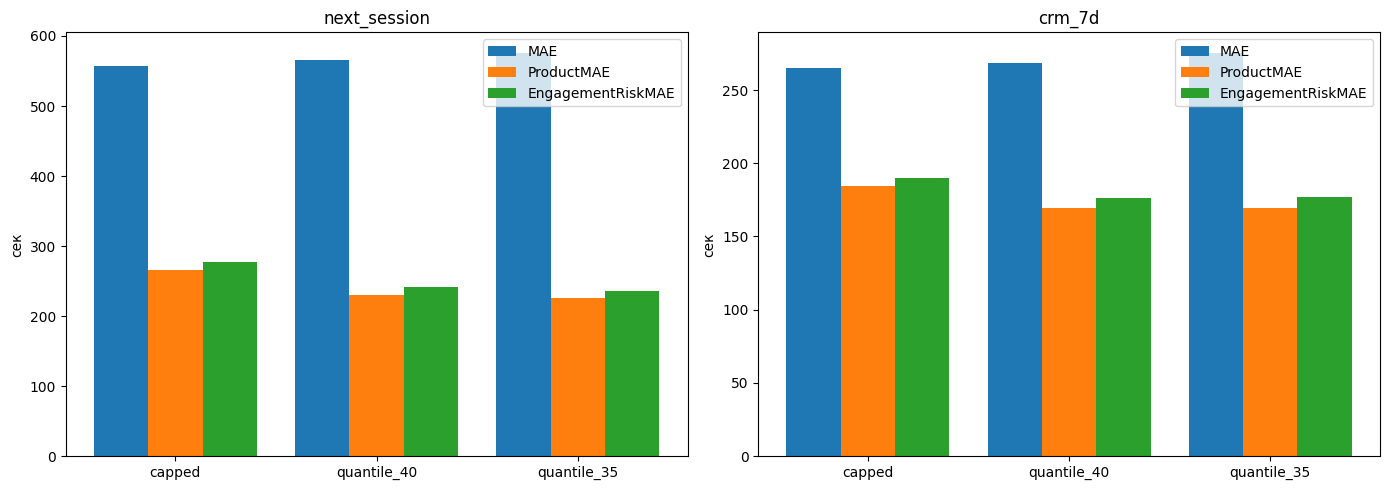

In [7]:
strat = ["cat_capped_target", "cat_quantile_40", "cat_quantile_35"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, lab in zip(axes, targets):
    sub = res[(res["target_label"] == lab) & (res["model_name"].isin(strat))].set_index("model_name").loc[strat]
    x = np.arange(len(sub))
    w = 0.27
    ax.bar(x - w, sub["val_mae"], w, label="MAE")
    ax.bar(x, sub["val_product_mae"], w, label="ProductMAE")
    ax.bar(x + w, sub["val_engagement_risk_mae"], w, label="EngagementRiskMAE")
    ax.set_xticks(x)
    ax.set_xticklabels(["capped", "quantile_40", "quantile_35"])
    ax.set_title(lab)
    ax.set_ylabel("сек")
    ax.legend()
plt.tight_layout()
plt.show()

## Ошибка по сегментам

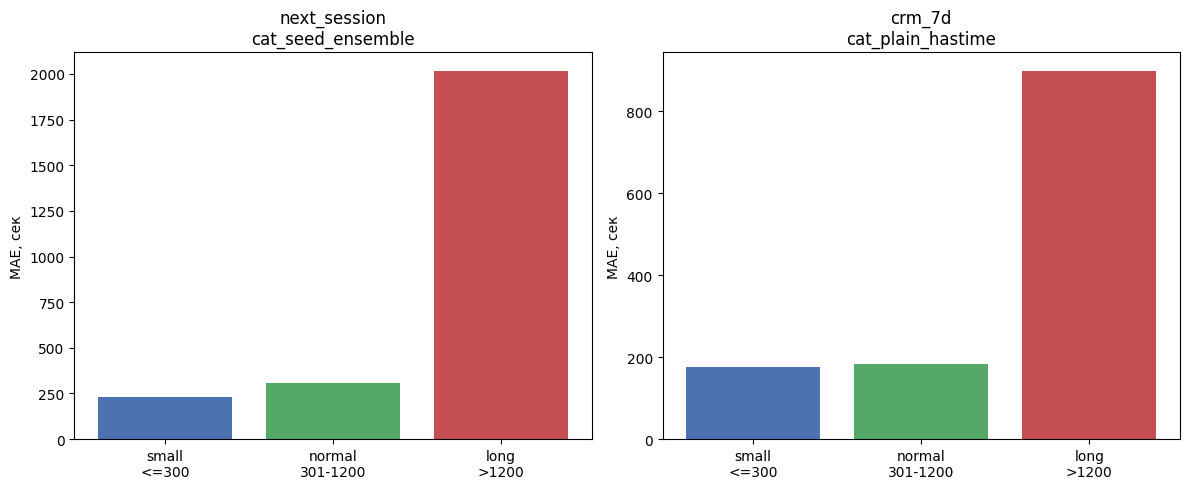

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, lab in zip(axes, targets):
    sub = res[(res["target_label"] == lab) & (res["model_family"].isin(sessionlevel))]
    best = sub.loc[sub["val_mae"].idxmin()]
    seg = [best["val_small_mae"], best["val_normal_mae"], best["val_long_mae"]]
    ax.bar(["small\n<=300", "normal\n301-1200", "long\n>1200"], seg,
           color=["#4c72b0", "#55a868", "#c44e52"])
    ax.set_title(lab + "\n" + best["model_name"])
    ax.set_ylabel("MAE, сек")
plt.tight_layout()
plt.show()

## Прогноз против факта

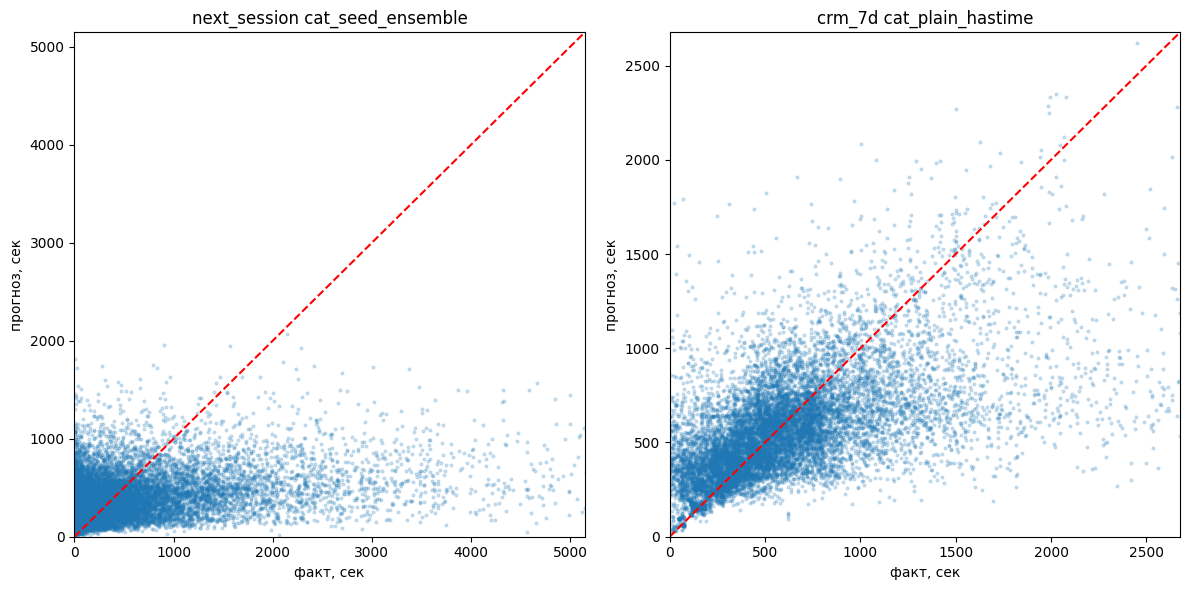

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, lab in zip(axes, targets):
    sub = res[(res["target_label"] == lab) & (res["model_family"].isin(sessionlevel))]
    best = sub.loc[sub["val_mae"].idxmin(), "model_name"]
    yt, yp = preds[(lab, best)]
    lim = np.percentile(yt, 99)
    ax.scatter(yt, yp, s=4, alpha=0.2)
    ax.plot([0, lim], [0, lim], "r--")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel("факт, сек")
    ax.set_ylabel("прогноз, сек")
    ax.set_title(lab + " " + best)
plt.tight_layout()
plt.show()

## Выигрыш над медианой

In [10]:
base = res[res["model_name"] == "dummy_median"].set_index("target_label")["val_mae"]
sub = res[res["model_family"].isin(sessionlevel)].copy()
sub["gain"] = 1 - sub["val_mae"] / sub["target_label"].map(base)
top = sub.sort_values("gain", ascending=False).groupby("target_label").head(3)
display(top[["target_label", "model_name", "val_mae", "gain"]].round(3))

,target_label,model_name,val_mae,gain
28,crm_7d,cat_plain_hastime,264.548,0.260
33,crm_7d,cat_capped_target,265.331,0.257
29,crm_7d,cat_ordered_hastime,266.183,0.255
42,next_session,cat_seed_ensemble,556.930,0.066
45,next_session,cat_blend_w75,557.115,0.065
37,next_session,cat_leaf_gradient_3,557.128,0.065


## Валидация против теста

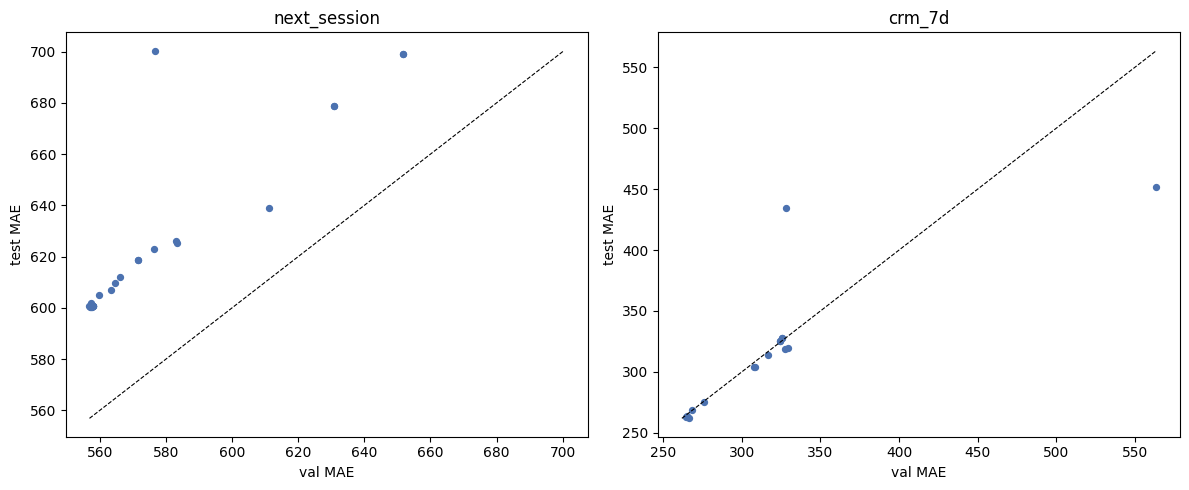

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, lab in zip(axes, targets):
    sub = res[(res["target_label"] == lab) & res["test_mae"].notna() & (res["model_family"].isin(sessionlevel))]
    ax.scatter(sub["val_mae"], sub["test_mae"], s=18, color="#4c72b0")
    lo = min(sub["val_mae"].min(), sub["test_mae"].min())
    hi = max(sub["val_mae"].max(), sub["test_mae"].max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.8)
    ax.set_xlabel("val MAE")
    ax.set_ylabel("test MAE")
    ax.set_title(lab)
plt.tight_layout()
plt.show()

## Сводные таблицы по семействам

In [12]:
def picktable(lab, names):
    sub = res[res["target_label"] == lab].set_index("model_name")
    sub = sub.loc[[n for n in names if n in sub.index]]
    return sub[["test_mae", "test_r2", "test_product_mae", "test_engagement_risk_mae", "test_long_mae"]].round(2)

print("next_session")
display(picktable("next_session", ["dummy_median", "huber_raw", "nn_num_qt_mae", "cat_plain_hastime", "cat_quantile_35"]))
print("crm_7d")
display(picktable("crm_7d", ["dummy_median", "huber_p995", "nn_num_qt_mae", "cat_plain_hastime", "cat_quantile_40"]))

next_session


,test_mae,test_r2,test_product_mae,test_engagement_risk_mae,test_long_mae
model_name,,,,,
dummy_median,639.69,-0.03,252.52,271.80,2502.80
huber_raw,618.80,0.02,287.24,308.93,2246.62
nn_num_qt_mae,606.92,0.03,257.78,274.99,2274.03
cat_plain_hastime,600.83,0.01,268.89,284.22,2224.49
cat_quantile_35,622.90,-0.03,231.02,243.31,2470.98


crm_7d


,test_mae,test_r2,test_product_mae,test_engagement_risk_mae,test_long_mae
model_name,,,,,
dummy_median,349.69,-0.07,232.71,249.96,1304.63
huber_p995,304.24,0.17,215.41,233.16,986.36
nn_num_qt_mae,313.68,0.09,210.30,222.86,1053.35
cat_plain_hastime,262.66,0.30,182.75,189.51,906.08
cat_quantile_40,268.96,0.23,173.69,180.72,1006.27


## Ансамбли против одиночной модели

In [13]:
ens = ["cat_ordered_hastime", "cat_seed_ensemble", "cat_blend_w50", "cat_nn_w70"]
sub = res[(res["target_label"] == "next_session") & (res["model_name"].isin(ens))]
display(sub[["model_name", "val_mae", "test_mae"]].round(2))

,model_name,val_mae,test_mae
27,cat_ordered_hastime,557.56,600.53
42,cat_seed_ensemble,556.93,600.69
44,cat_blend_w50,557.16,600.66
48,cat_nn_w70,557.24,601.90


## MedAE по моделям

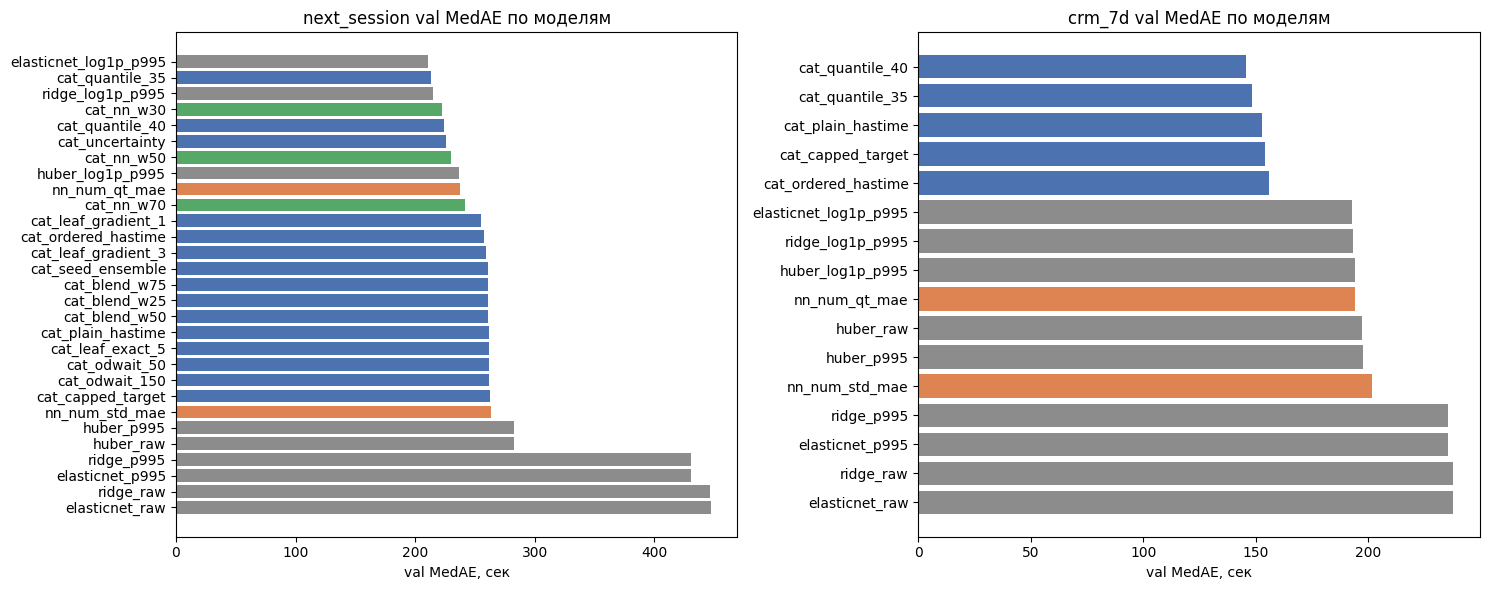

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, lab in zip(axes, targets):
    sub = res[(res["target_label"] == lab) & (res["model_family"].isin(sessionlevel))].sort_values("val_medae")
    ax.barh(sub["model_name"], sub["val_medae"], color=[colors[f] for f in sub["model_family"]])
    ax.invert_yaxis()
    ax.set_title(lab + " val MedAE по моделям")
    ax.set_xlabel("val MedAE, сек")
plt.tight_layout()
plt.show()

## Остатки лучших моделей

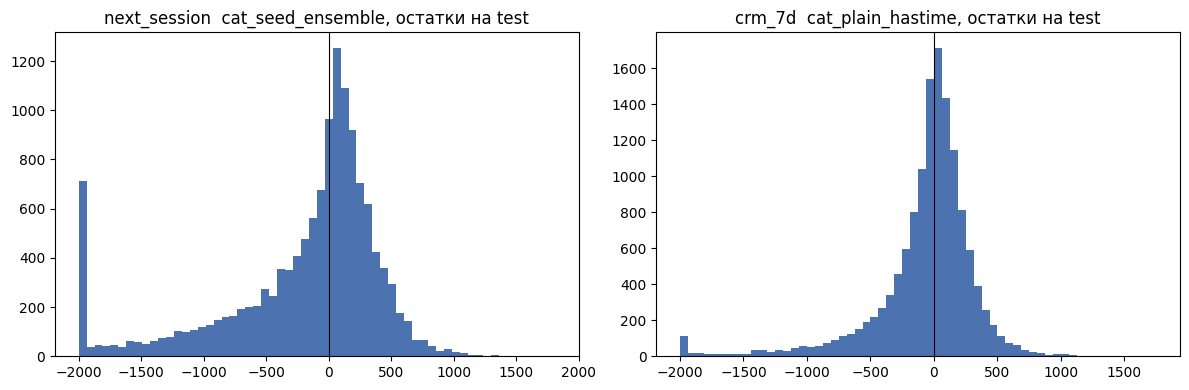

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, lab in zip(axes, targets):
    sub = res[(res["target_label"] == lab) & (res["model_family"].isin(sessionlevel))]
    best = sub.loc[sub["val_mae"].idxmin(), "model_name"]
    yt, yp = preds[(lab, best)]
    ax.hist(np.clip(yp - yt, -2000, 2000), bins=60, color="#4c72b0")
    ax.axvline(0, color="k", lw=0.8)
    ax.set_title(lab + "  " + best + ", остатки на test")
plt.tight_layout()
plt.show()

## Время обучения

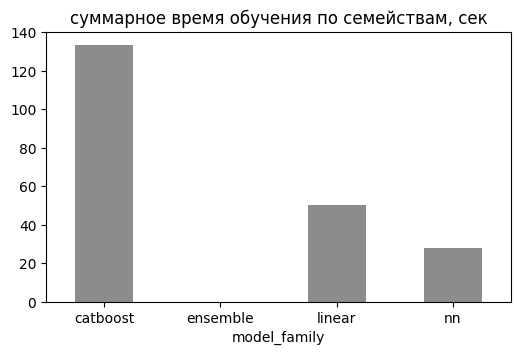

In [16]:
sub = res[res["model_family"].isin(sessionlevel)].groupby("model_family")["fit_sec"].sum()
sub.plot.bar(color="#8c8c8c", rot=0, figsize=(6, 3.5), title="суммарное время обучения по семействам, сек")
plt.show()

## Выводы
- next_session почти непредсказуем: R2 у всех моделей около нуля, заметно обойти медиану не удаётся никому
- crm_7d предсказуем заметно лучше: сильнее всех бустинг, нейросеть с QuantileTransformer чуть позади, линейные модели слабее обеих
- ансамбли прироста не дают, в итоговом решении одиночная модель
- backtest и разные random seed показывают что качество основной модели устойчиво